Imports et chargements

Ce bloc importe les données et prépare les bibliothèques nécessaires pour le clustering KMeans et l'ACP.

In [35]:
import os
os.environ['OMP_NUM_THREADS'] = '2'

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_mat = pd.read_csv("../dataset/student-mat.csv")
df_por = pd.read_csv("../dataset/student-por.csv")

KMeans

Ce code réalise un clustering KMeans sur les données encodées et standardisées pour détecter des groupes d'étudiants similaires.

In [36]:
from sklearn.cluster import KMeans

datasets = {
    "Math": df_mat,
    "Portuguese": df_por
}

pca_results = {}

for name, df in datasets.items():

    df_encoded = pd.get_dummies(df, drop_first=True)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(df_encoded)

    pca = PCA()

    X_pca = pca.fit_transform(X_scaled)

    pca_results[name] = {
        "df_encoded": df_encoded,
        "X_scaled": X_scaled,
        "pca": pca,
        "X_pca": X_pca
    }

kmeans_results = {}
cluster_colors = ["#ff6b6b", "#ffd93d", "#6bcf7f"]

for name, result in pca_results.items():

    kmeans = KMeans(
        n_clusters=3,
        random_state=42
    )

    clusters = kmeans.fit_predict(result["X_scaled"])

    kmeans_results[name] = clusters

Visualisation KMeans

Cette cellule projette les clusters KMeans sur les deux premières composantes principales pour visualiser leur séparation.

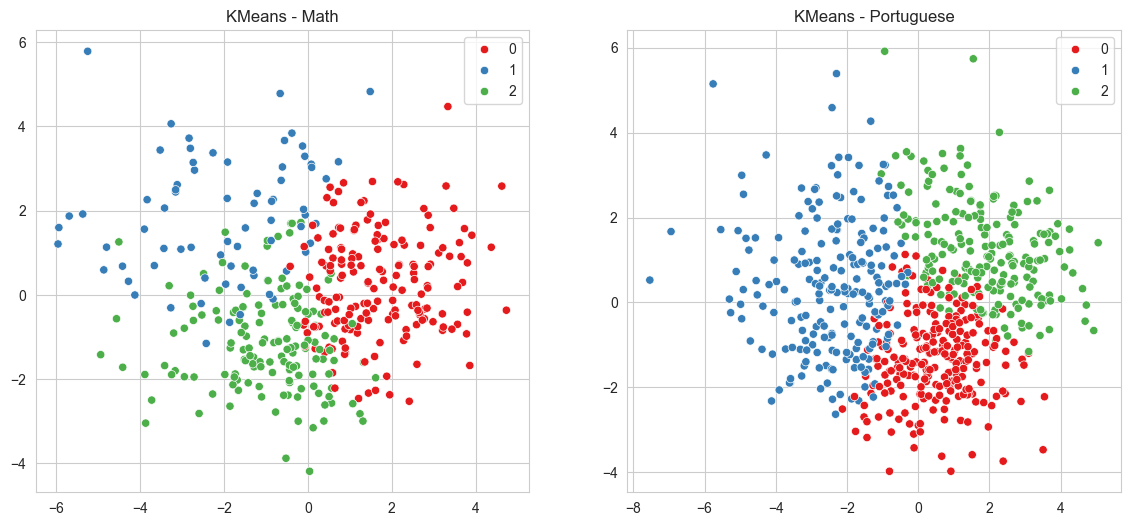

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

pca_2d_results = {}

for name, result in pca_results.items():

    pca_2d = PCA(n_components=2)

    X_pca_2d = pca_2d.fit_transform(result["X_scaled"])

    pca_2d_results[name] = {
        "pca_2d": pca_2d,
        "X_pca_2d": X_pca_2d
    }

for ax, name in zip(axes, ["Math", "Portuguese"]):

    X = pca_2d_results[name]["X_pca_2d"]

    sns.scatterplot(
        x=X[:,0],
        y=X[:,1],
        hue=kmeans_results[name],
        palette="Set1",
        ax=ax
    )

    ax.set_title(f"KMeans - {name}")

plt.show()

CAH

Ce bloc réalise une classification hiérarchique ascendante pour explorer l'organisation des observations en dendrogramme.

Les dendrogrammes servent à visualiser une structure hiérarchique complémentaire. Les clusters utilisés ensuite pour analyser les variables sont ceux du KMeans, pas des coupes de la CAH.

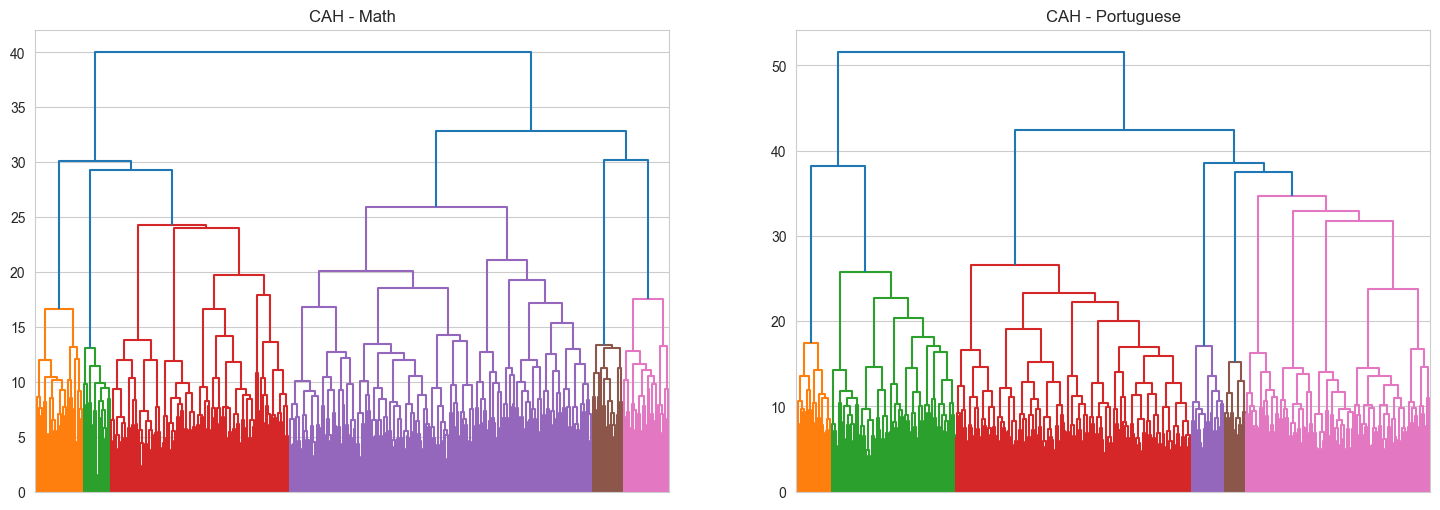

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram

fig, axes = plt.subplots(1, 2, figsize=(18,6))

for ax, (name, result) in zip(axes, pca_results.items()):

    Z = linkage(
        result["X_scaled"],
        method='ward'
    )

    dendrogram(
        Z,
        ax=ax,
        no_labels=True
    )

    ax.set_title(f"CAH - {name}")

plt.show()

## Analyse détaillée : Distribution des clusters par variables

Cette section montre comment les groupes formés par KMeans se répartissent selon l'alcool, les parents, le sexe et les absences.

Note : les clusters étudiés dans les graphiques suivants sont les clusters KMeans. Le dendrogramme CAH est affiché pour comparaison visuelle, mais il n'est pas utilisé directement pour le profilage par variable.

ANALYSE CLUSTERS - CONSOMMATION D'ALCOOL

Math - Alcool semaine (Dalc) par cluster:
Dalc     1   2   3  4  5  All
row_0                        
0      134  33   5  0  1  173
1       15  21  19  9  8   72
2      127  21   2  0  0  150
All    276  75  26  9  9  395

Math - Alcool weekend (Walc) par cluster:
Walc     1   2   3   4   5  All
row_0                          
0       69  45  38  16   5  173
1        0   5  18  26  23   72
2       82  35  24   9   0  150
All    151  85  80  51  28  395

Portuguese - Alcool semaine (Dalc) par cluster:
Dalc     1    2   3   4   5  All
row_0                           
0      202   36   3   1   2  244
1      111   46  24  12  12  205
2      138   39  16   4   3  200
All    451  121  43  17  17  649

Portuguese - Alcool weekend (Walc) par cluster:
Walc     1    2    3   4   5  All
row_0                            
0      122   68   35  17   2  244
1       51   38   46  42  28  205
2       74   44   39  28  15  200
All    247  150  120  87  45  649


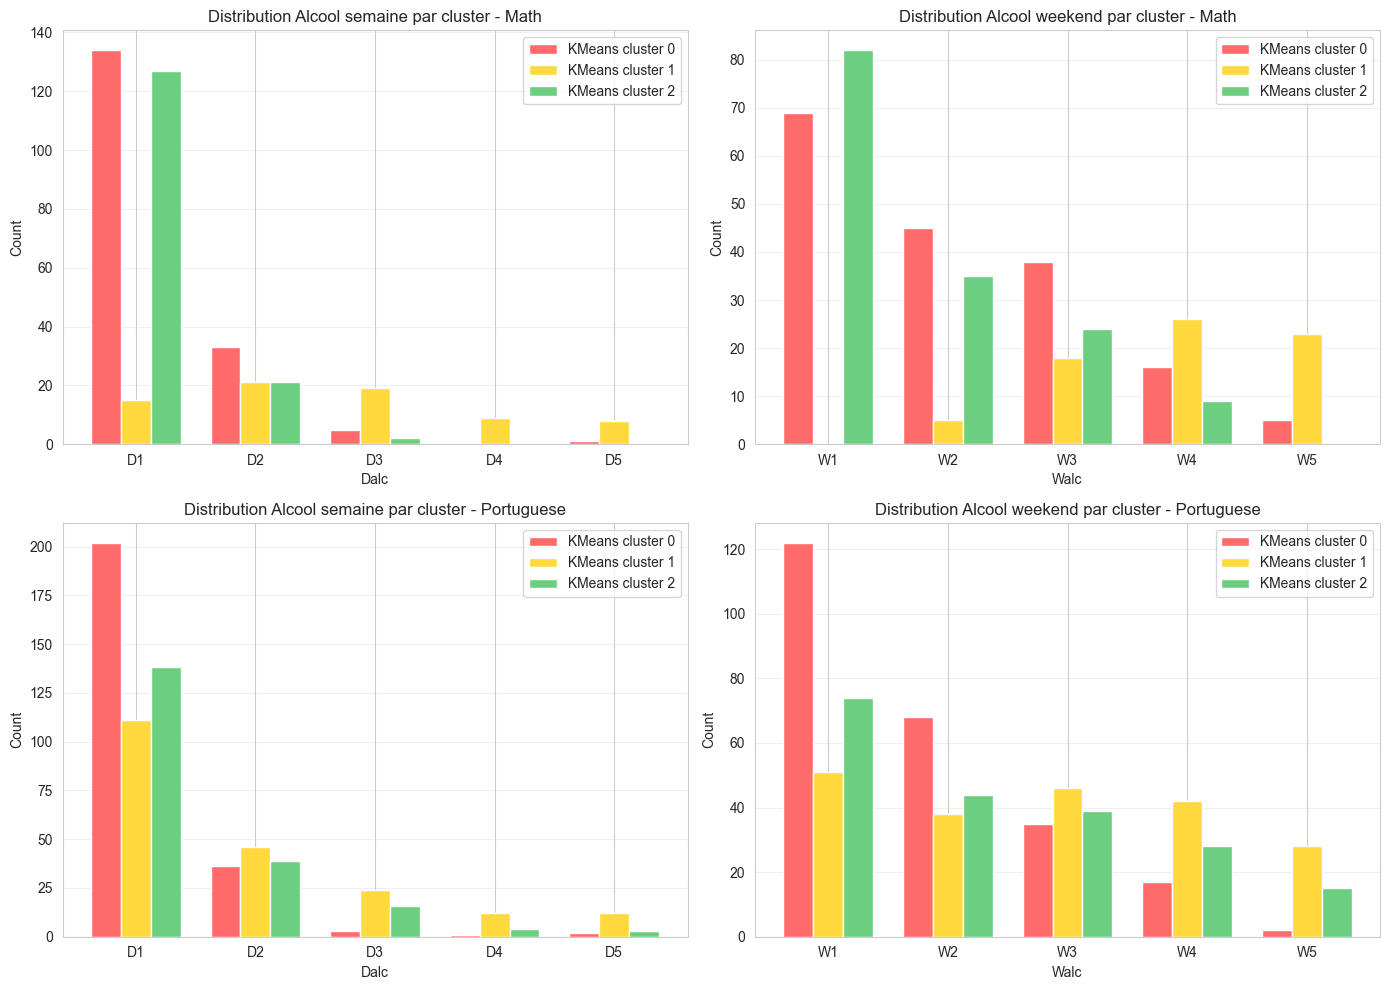


ANALYSE CLUSTERS - ÉDUCATION DES PARENTS

Math - Éducation mère (Medu) par cluster:
Medu   0   1    2   3    4  All
row_0                          
0      1   6   28  39   99  173
1      1  25   17  16   13   72
2      1  28   58  44   19  150
All    3  59  103  99  131  395

Math - Éducation père (Fedu) par cluster:
Fedu   0   1    2    3   4  All
row_0                          
0      2  11   41   49  70  173
1      0  27   24   11  10   72
2      0  44   50   40  16  150
All    2  82  115  100  96  395

Portuguese - Éducation mère (Medu) par cluster:
Medu   0    1    2    3    4  All
row_0                            
0      3   57  101   59   24  244
1      3   86   61   43   12  205
2      0    0   24   37  139  200
All    6  143  186  139  175  649

Portuguese - Éducation père (Fedu) par cluster:
Fedu   0    1    2    3    4  All
row_0                            
0      4   77  103   44   16  244
1      3   89   73   29   11  205
2      0    8   33   58  101  200
All    7  174  2

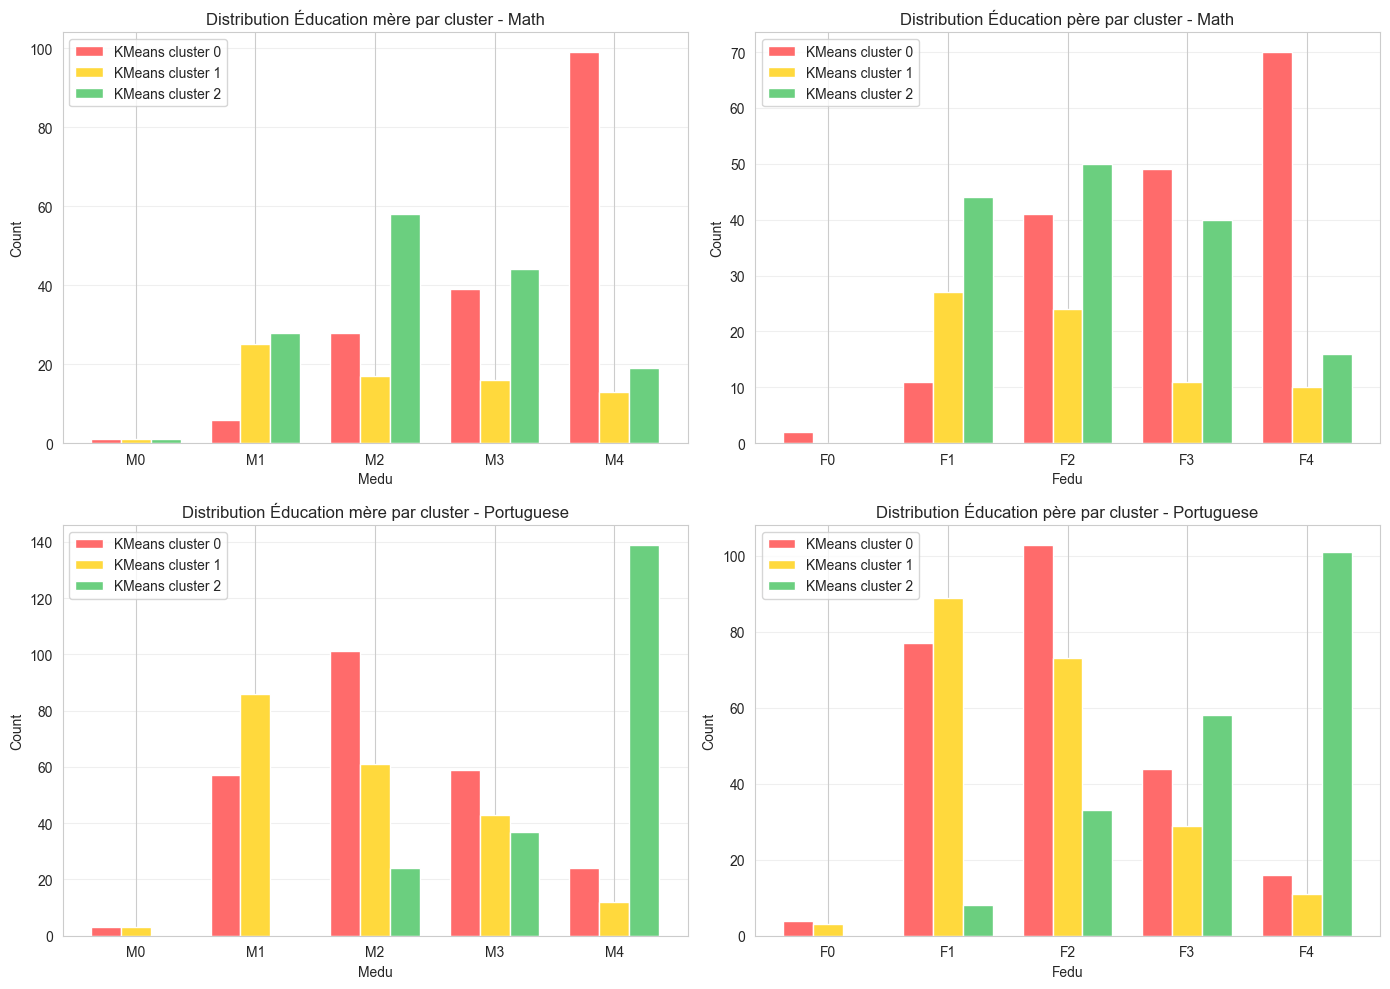


ANALYSE CLUSTERS - SEXE ET ABSENCES

Math - Sexe par cluster:
sex      F    M  All
row_0               
0       77   96  173
1       11   61   72
2      120   30  150
All    208  187  395

Math - Absences moyenne par cluster:
             mean        std  count
Cluster                            
0        4.479769   5.156380    173
1        6.125000   6.148256     72
2        6.926667  10.831905    150

Portuguese - Sexe par cluster:
sex      F    M  All
row_0               
0      187   57  244
1       99  106  205
2       97  103  200
All    383  266  649

Portuguese - Absences moyenne par cluster:
             mean       std  count
Cluster                           
0        3.307377  4.427722    244
1        4.278049  5.113013    205
2        3.455000  4.336126    200


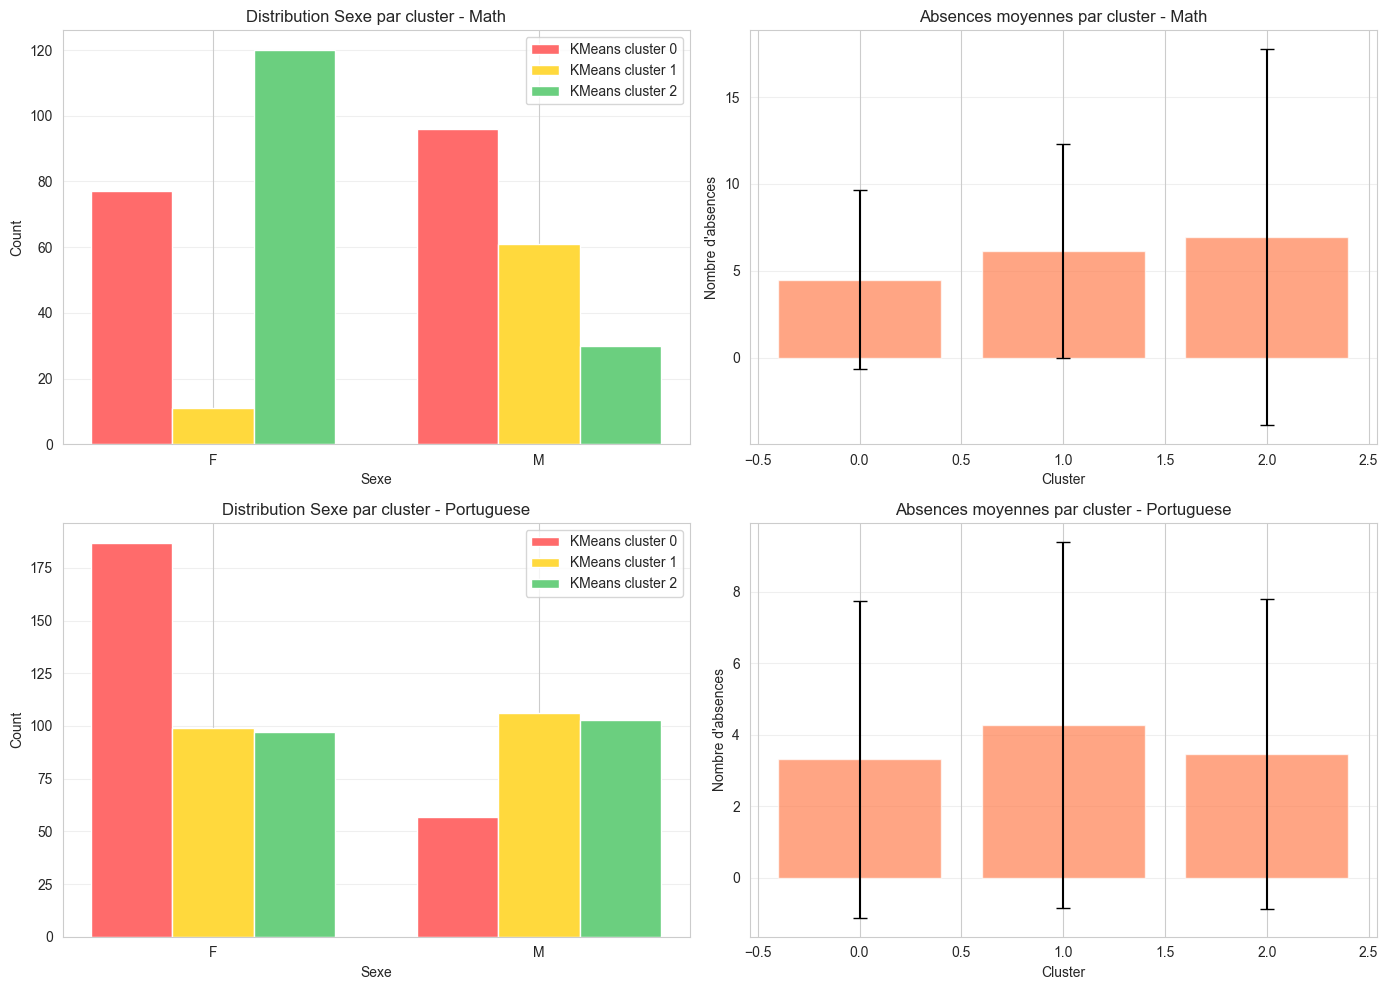

In [39]:
### Distribution des clusters par Alcool

print("=" * 60)
print("ANALYSE CLUSTERS - CONSOMMATION D'ALCOOL")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    clusters = kmeans_results[name]
    
    # Alcool semaine (Dalc)
    print(f"\n{name} - Alcool semaine (Dalc) par cluster:")
    dalc_cluster = pd.crosstab(clusters, df["Dalc"], margins=True)
    print(dalc_cluster)
    
    cluster_dalc_mean = df.groupby("Dalc")["Dalc"].count()
    dalc_means = []
    cluster_labels = []
    for cluster_id in range(3):
        mask = clusters == cluster_id
        for dalc_val in sorted(df["Dalc"].unique()):
            dalc_means.append(df[mask & (df["Dalc"] == dalc_val)]["Dalc"].mean())
            cluster_labels.append(f"C{cluster_id}-D{dalc_val}")
    
    # Plot Dalc - Distribution des clusters
    dalc_dist = []
    for dalc_val in sorted(df["Dalc"].unique()):
        for cluster_id in range(3):
            mask = clusters == cluster_id
            count = (df[mask]["Dalc"] == dalc_val).sum()
            dalc_dist.append(count)
    
    x_labels = [f"D{v}" for v in sorted(df["Dalc"].unique())]
    x_pos = np.arange(len(x_labels))
    width = 0.25
    
    for cluster_id in range(3):
        mask = clusters == cluster_id
        counts = [(df[mask]["Dalc"] == v).sum() for v in sorted(df["Dalc"].unique())]
        axes[ax_idx, 0].bar(x_pos + cluster_id*width, counts, width, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
    
    axes[ax_idx, 0].set_title(f"Distribution Alcool semaine par cluster - {name}")
    axes[ax_idx, 0].set_xlabel("Dalc")
    axes[ax_idx, 0].set_ylabel("Count")
    axes[ax_idx, 0].set_xticks(x_pos + width)
    axes[ax_idx, 0].set_xticklabels(x_labels)
    axes[ax_idx, 0].legend()
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    # Alcool weekend (Walc)
    print(f"\n{name} - Alcool weekend (Walc) par cluster:")
    walc_cluster = pd.crosstab(clusters, df["Walc"], margins=True)
    print(walc_cluster)
    
    x_labels = [f"W{v}" for v in sorted(df["Walc"].unique())]
    x_pos = np.arange(len(x_labels))
    
    for cluster_id in range(3):
        mask = clusters == cluster_id
        counts = [(df[mask]["Walc"] == v).sum() for v in sorted(df["Walc"].unique())]
        axes[ax_idx, 1].bar(x_pos + cluster_id*width, counts, width, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
    
    axes[ax_idx, 1].set_title(f"Distribution Alcool weekend par cluster - {name}")
    axes[ax_idx, 1].set_xlabel("Walc")
    axes[ax_idx, 1].set_ylabel("Count")
    axes[ax_idx, 1].set_xticks(x_pos + width)
    axes[ax_idx, 1].set_xticklabels(x_labels)
    axes[ax_idx, 1].legend()
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution des clusters par Éducation des parents

print("\n" + "=" * 60)
print("ANALYSE CLUSTERS - ÉDUCATION DES PARENTS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    clusters = kmeans_results[name]
    
    # Medu
    print(f"\n{name} - Éducation mère (Medu) par cluster:")
    medu_cluster = pd.crosstab(clusters, df["Medu"], margins=True)
    print(medu_cluster)
    
    # Fedu
    print(f"\n{name} - Éducation père (Fedu) par cluster:")
    fedu_cluster = pd.crosstab(clusters, df["Fedu"], margins=True)
    print(fedu_cluster)
    
    x_labels = [f"M{v}" for v in sorted(df["Medu"].unique())]
    x_pos = np.arange(len(x_labels))
    width = 0.25
    
    for cluster_id in range(3):
        mask = clusters == cluster_id
        counts = [(df[mask]["Medu"] == v).sum() for v in sorted(df["Medu"].unique())]
        axes[ax_idx, 0].bar(x_pos + cluster_id*width, counts, width, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
    
    axes[ax_idx, 0].set_title(f"Distribution Éducation mère par cluster - {name}")
    axes[ax_idx, 0].set_xlabel("Medu")
    axes[ax_idx, 0].set_ylabel("Count")
    axes[ax_idx, 0].set_xticks(x_pos + width)
    axes[ax_idx, 0].set_xticklabels(x_labels)
    axes[ax_idx, 0].legend()
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    x_labels = [f"F{v}" for v in sorted(df["Fedu"].unique())]
    x_pos = np.arange(len(x_labels))
    
    for cluster_id in range(3):
        mask = clusters == cluster_id
        counts = [(df[mask]["Fedu"] == v).sum() for v in sorted(df["Fedu"].unique())]
        axes[ax_idx, 1].bar(x_pos + cluster_id*width, counts, width, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
    
    axes[ax_idx, 1].set_title(f"Distribution Éducation père par cluster - {name}")
    axes[ax_idx, 1].set_xlabel("Fedu")
    axes[ax_idx, 1].set_ylabel("Count")
    axes[ax_idx, 1].set_xticks(x_pos + width)
    axes[ax_idx, 1].set_xticklabels(x_labels)
    axes[ax_idx, 1].legend()
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution des clusters par Sexe et Absences

print("\n" + "=" * 60)
print("ANALYSE CLUSTERS - SEXE ET ABSENCES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    clusters = kmeans_results[name]
    
    # Sexe
    print(f"\n{name} - Sexe par cluster:")
    sex_cluster = pd.crosstab(clusters, df["sex"], margins=True)
    print(sex_cluster)
    
    # Absences moyenne par cluster
    print(f"\n{name} - Absences moyenne par cluster:")
    abs_by_cluster = pd.DataFrame({
        "Cluster": clusters,
        "Absences": df["absences"].values
    }).groupby("Cluster")["Absences"].agg(["mean", "std", "count"])
    print(abs_by_cluster)
    
    # Plot Sexe
    x_labels = list(df["sex"].unique())
    x_pos = np.arange(len(x_labels))
    width = 0.25
    
    for cluster_id in range(3):
        mask = clusters == cluster_id
        counts = [(df[mask]["sex"] == v).sum() for v in x_labels]
        axes[ax_idx, 0].bar(x_pos + cluster_id*width, counts, width, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
    
    axes[ax_idx, 0].set_title(f"Distribution Sexe par cluster - {name}")
    axes[ax_idx, 0].set_xlabel("Sexe")
    axes[ax_idx, 0].set_ylabel("Count")
    axes[ax_idx, 0].set_xticks(x_pos + width)
    axes[ax_idx, 0].set_xticklabels(x_labels)
    axes[ax_idx, 0].legend()
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    # Plot Absences
    abs_means = []
    abs_stds = []
    for cluster_id in range(3):
        mask = clusters == cluster_id
        abs_means.append(df[mask]["absences"].mean())
        abs_stds.append(df[mask]["absences"].std())
    
    axes[ax_idx, 1].bar(range(3), abs_means, color="coral", alpha=0.7, yerr=abs_stds, capsize=5)
    axes[ax_idx, 1].set_title(f"Absences moyennes par cluster - {name}")
    axes[ax_idx, 1].set_xlabel("Cluster")
    axes[ax_idx, 1].set_ylabel("Nombre d'absences")
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


ANALYSE CENTRALE : G3 MOYEN PAR CLUSTER

Math - Notes (G3) moyennes par cluster:
             mean       std  count
Cluster                           
0        13.49711  2.924683    173
1         9.00000  3.838280     72
2         7.54000  4.276720    150

Portuguese - Notes (G3) moyennes par cluster:
              mean       std  count
Cluster                            
0        13.143443  2.209202    244
1         8.960976  2.993201    205
2        13.415000  2.396139    200


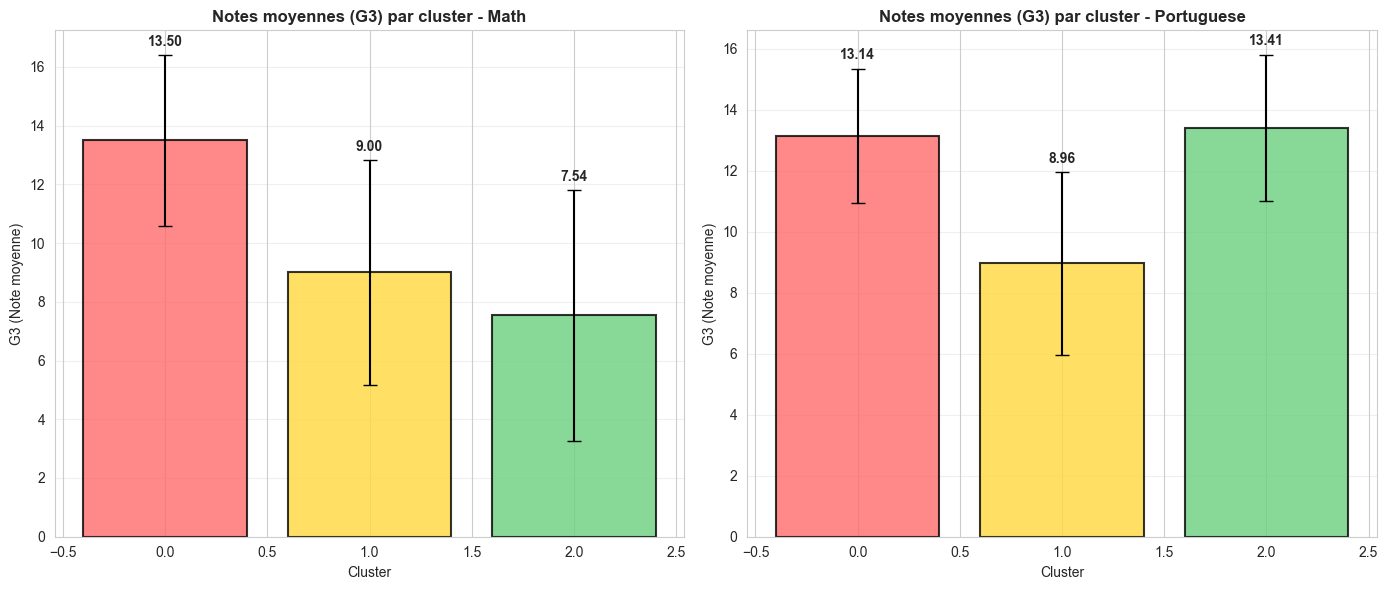


ANALYSE : IMPACT DES VARIABLES SUR G3 SELON LES CLUSTERS

--- Math ---

--- Portuguese ---


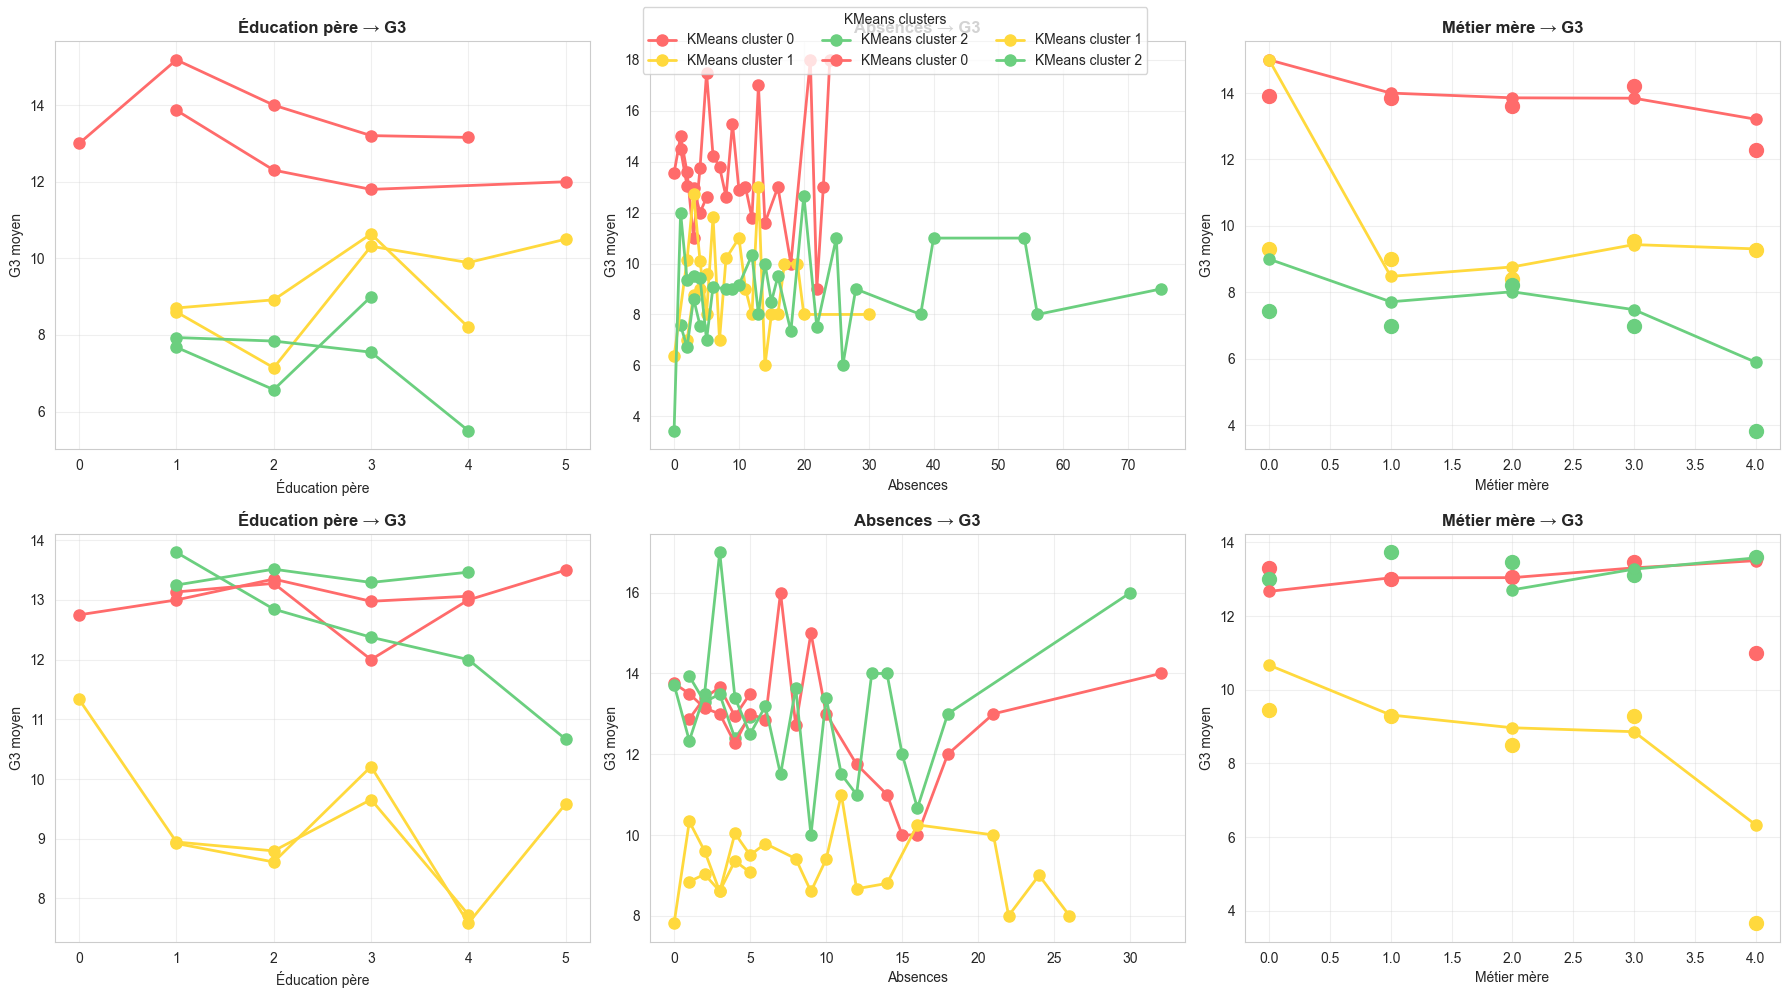

In [40]:
### G3 MOYEN (NOTES) PAR CLUSTER - ANALYSE CENTRALE

print("\n" + "=" * 60)
print("ANALYSE CENTRALE : G3 MOYEN PAR CLUSTER")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    clusters = kmeans_results[name]
    
    # G3 moyenne par cluster
    print(f"\n{name} - Notes (G3) moyennes par cluster:")
    g3_by_cluster = pd.DataFrame({
        "Cluster": clusters,
        "G3": df["G3"].values
    }).groupby("Cluster")["G3"].agg(["mean", "std", "count"])
    print(g3_by_cluster)
    
    g3_means = []
    g3_stds = []
    for cluster_id in range(3):
        mask = clusters == cluster_id
        g3_means.append(df[mask]["G3"].mean())
        g3_stds.append(df[mask]["G3"].std())
    
    axes[ax_idx].bar(range(3), g3_means, color=["#ff6b6b", "#ffd93d", "#6bcf7f"], alpha=0.8, yerr=g3_stds, capsize=5, edgecolor='black', linewidth=1.5)
    axes[ax_idx].set_title(f"Notes moyennes (G3) par cluster - {name}", fontsize=12, fontweight='bold')
    axes[ax_idx].set_xlabel("Cluster")
    axes[ax_idx].set_ylabel("G3 (Note moyenne)")
    axes[ax_idx].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, (mean, std) in enumerate(zip(g3_means, g3_stds)):
        axes[ax_idx].text(i, mean + std + 0.3, f"{mean:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### CORRÉLATION : Variables vs G3 PAR CLUSTER

print("\n" + "=" * 60)
print("ANALYSE : IMPACT DES VARIABLES SUR G3 SELON LES CLUSTERS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables_to_check = [("Dalc", "Alcool semaine"), ("Walc", "Alcool weekend"), 
                       ("Medu", "Éducation mère"), ("Fedu", "Éducation père"),
                       ("absences", "Absences"), ("Mjob", "Métier mère")]

for plot_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    clusters = kmeans_results[name]
    
    print(f"\n--- {name} ---")
    
    for var_idx, (var_name, var_label) in enumerate(variables_to_check):
        ax = axes[plot_idx, var_idx % 3] if var_idx < 3 else axes[plot_idx, var_idx - 3]
        
        # Pour chaque cluster, montrer la corrélation ou moyenne de G3 par variable
        for cluster_id in range(3):
            mask = clusters == cluster_id
            cluster_data = df[mask]
            
            if var_name in ["Dalc", "Walc", "Medu", "Fedu", "absences"]:
                # Variables numériques
                g3_means_by_var = cluster_data.groupby(var_name)["G3"].mean()
                ax.plot(g3_means_by_var.index, g3_means_by_var.values, marker='o', 
                       color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}", linewidth=2, markersize=8)
            else:
                # Variables catégoriques
                g3_means_by_var = cluster_data.groupby(var_name)["G3"].mean()
                positions = range(len(g3_means_by_var))
                ax.scatter(positions, g3_means_by_var.values, s=100, color=cluster_colors[cluster_id], label=f"KMeans cluster {cluster_id}")
        
        ax.set_title(f"{var_label} → G3", fontweight='bold')
        ax.set_xlabel(var_label)
        ax.set_ylabel("G3 moyen")
        ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, title='KMeans clusters')
plt.tight_layout()
plt.show()

## Analyse KMeans approfondie

Cette section approfondit la structure des clusters KMeans avec une mesure de qualité, la taille des groupes et un profil des moyennes de variables clés.


ANALYSE APPROFONDIE KMEANS - Math
Silhouette score : 0.052

Taille des clusters KMeans :
0    173
1     72
2    150
Name: count, dtype: int64

Profil des clusters KMeans (moyennes) :
         G3_mean  absences_mean  Dalc_mean  Walc_mean  Medu_mean  Fedu_mean
Cluster                                                                    
0          13.50           4.48       1.27       2.09       3.32       3.01
1           9.00           6.12       2.64       3.93       2.21       2.06
2           7.54           6.93       1.17       1.73       2.35       2.19


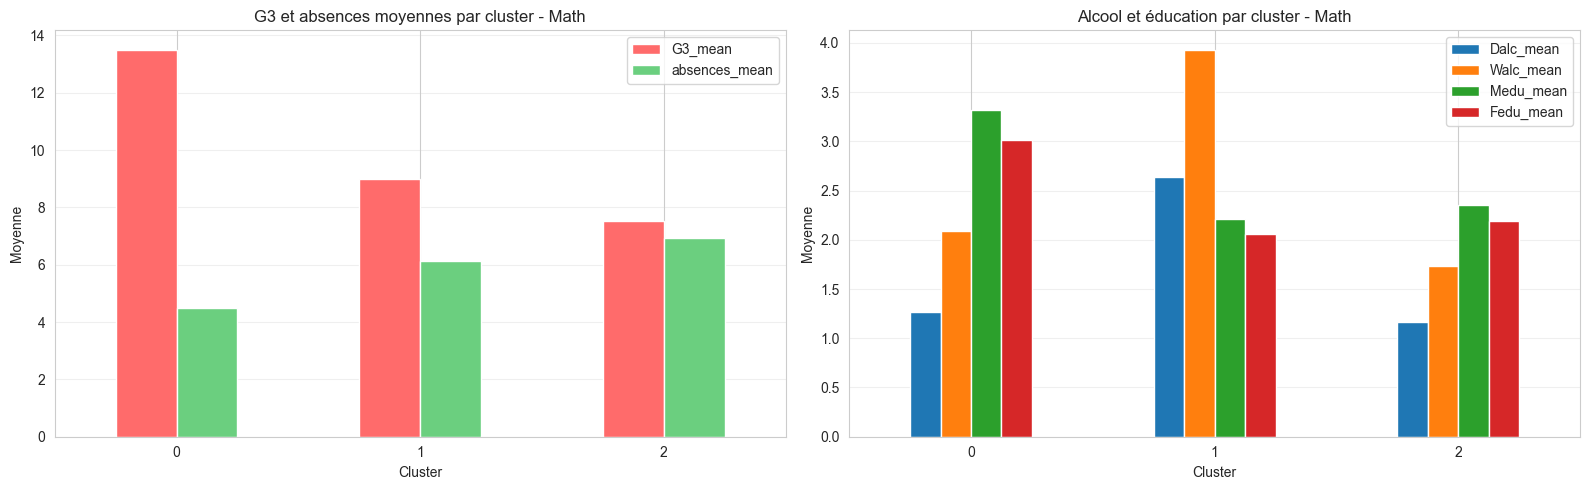


ANALYSE APPROFONDIE KMEANS - Portuguese
Silhouette score : 0.047

Taille des clusters KMeans :
0    244
1    205
2    200
Name: count, dtype: int64

Profil des clusters KMeans (moyennes) :
         G3_mean  absences_mean  Dalc_mean  Walc_mean  Medu_mean  Fedu_mean
Cluster                                                                    
0          13.14           3.31       1.22       1.81       2.18       1.96
1           8.96           4.28       1.87       2.80       1.88       1.79
2          13.42           3.46       1.48       2.33       3.58       3.26


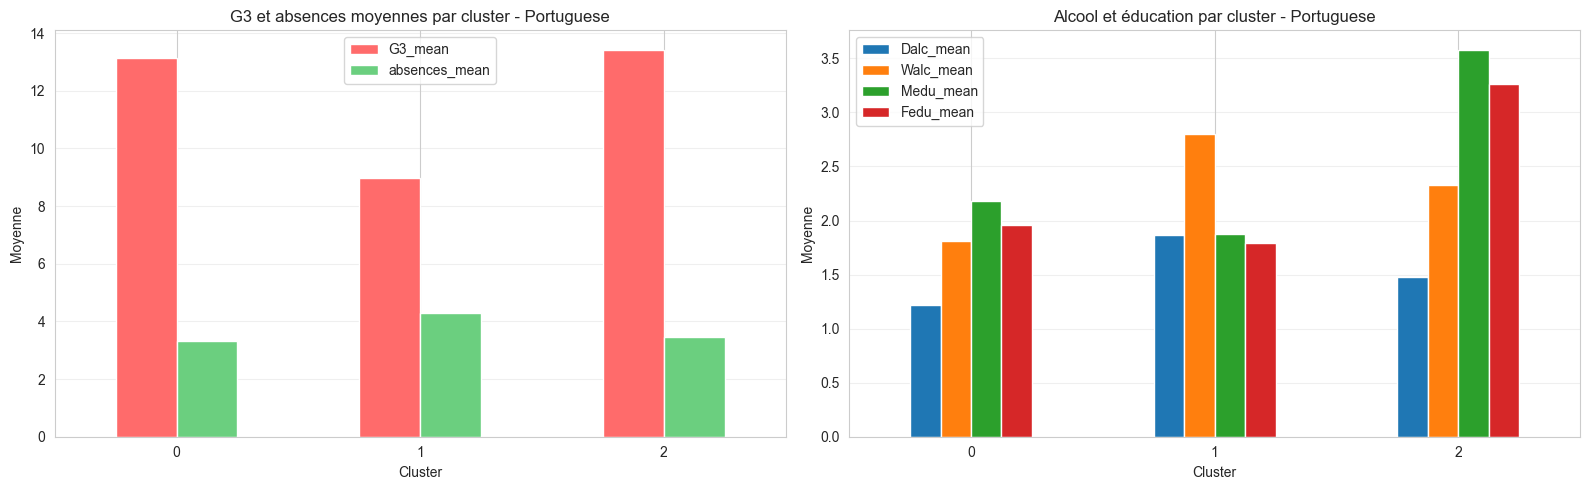

In [41]:
from sklearn.metrics import silhouette_score

for name, df in [("Math", df_mat), ("Portuguese", df_por)]:
    clusters = kmeans_results[name]
    X_scaled = pca_results[name]["X_scaled"]

    silhouette = silhouette_score(X_scaled, clusters)
    print("\n" + "=" * 60)
    print(f"ANALYSE APPROFONDIE KMEANS - {name}")
    print("=" * 60)
    print(f"Silhouette score : {silhouette:.3f}")

    counts = pd.Series(clusters).value_counts().sort_index()
    print("\nTaille des clusters KMeans :")
    print(counts)

    df_profile = df.copy()
    df_profile["Cluster"] = clusters
    summary = df_profile.groupby("Cluster").agg(
        G3_mean=("G3", "mean"),
        absences_mean=("absences", "mean"),
        Dalc_mean=("Dalc", "mean"),
        Walc_mean=("Walc", "mean"),
        Medu_mean=("Medu", "mean"),
        Fedu_mean=("Fedu", "mean")
    ).round(2)

    print("\nProfil des clusters KMeans (moyennes) :")
    print(summary)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    summary[["G3_mean", "absences_mean"]].plot(kind="bar", ax=axes[0], rot=0, color=["#ff6b6b", "#6bcf7f"])
    axes[0].set_title(f"G3 et absences moyennes par cluster - {name}")
    axes[0].set_ylabel("Moyenne")
    axes[0].grid(axis='y', alpha=0.3)

    summary[["Dalc_mean", "Walc_mean", "Medu_mean", "Fedu_mean"]].plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title(f"Alcool et éducation par cluster - {name}")
    axes[1].set_ylabel("Moyenne")
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

Analyse CAH complémentaire après KMeans
Cette section compare les clusters formés par la CAH avec ceux du KMeans. Elle montre la distribution des groupes hiérarchiques, leurs moyennes de G3 et quelques variables clés pour mieux comprendre les similarités et différences.


ANALYSE CAH POST-KMEANS - Math

Comparaison KMeans vs CAH (effectifs):
CAH       1    2   3
KMeans              
0       119   50   4
1        15   39  18
2        24  100  26

Adjusted Rand Index (KMeans vs CAH) : 0.179
Silhouette score CAH : 0.043

Taille des clusters CAH :
CAH_cluster
1    158
2    189
3     48
Name: count, dtype: int64

Profil des clusters CAH (moyennes) :
             G3_mean  absences_mean  Dalc_mean  Walc_mean  Medu_mean  \
CAH_cluster                                                            
1              12.17           6.00       1.51       2.30       3.39   
2               9.52           4.98       1.41       2.22       2.34   
3               8.15           7.60       1.67       2.52       2.23   

             Fedu_mean  
CAH_cluster             
1                 3.15  
2                 2.13  
3                 1.98  


C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="G3", data=df, estimator="mean", ax=axes[0], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="absences", data=df, estimator="mean", ax=axes[1], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="Dalc", data=df, estima

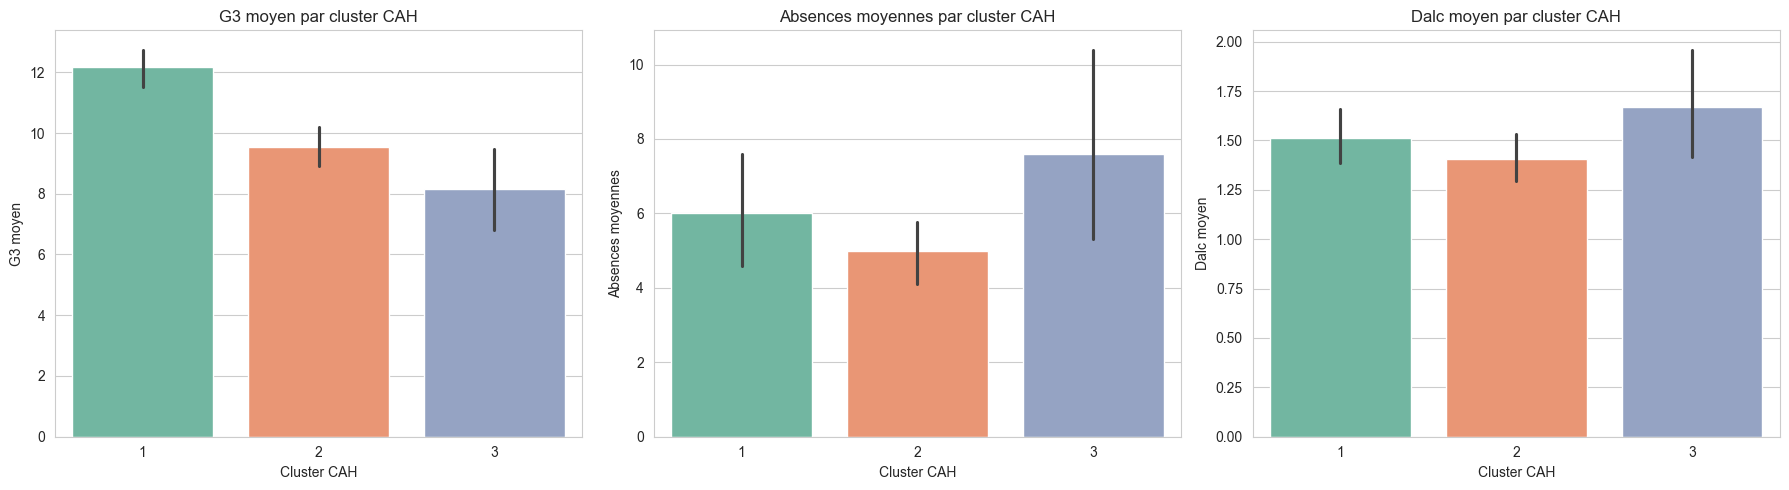


Comparaison CAH vs KMeans par note moyenne de G3 :
CAH_cluster             1          2          3
KMeans_cluster                                 
0               13.403361  13.640000  14.500000
1                9.866667   9.487179   7.222222
2                7.500000   7.480000   7.807692


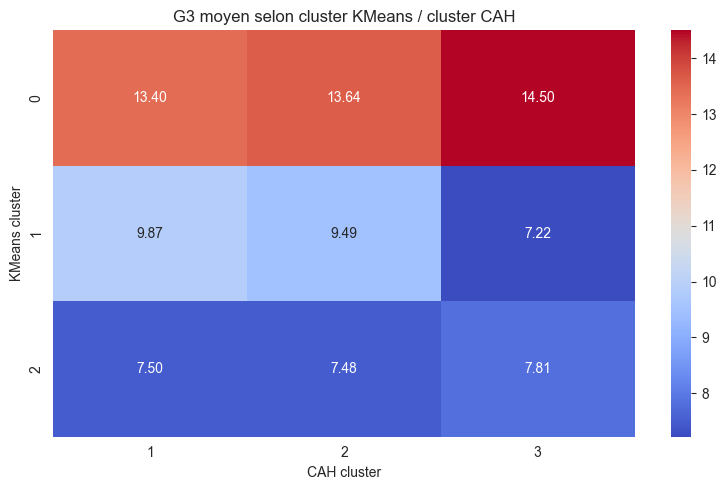


ANALYSE CAH POST-KMEANS - Portuguese

Comparaison KMeans vs CAH (effectifs):
CAH       1    2    3
KMeans               
0        24  191   29
1       130   32   43
2         9   19  172

Adjusted Rand Index (KMeans vs CAH) : 0.412
Silhouette score CAH : 0.028

Taille des clusters CAH :
CAH_cluster
1    163
2    242
3    244
Name: count, dtype: int64

Profil des clusters CAH (moyennes) :
             G3_mean  absences_mean  Dalc_mean  Walc_mean  Medu_mean  \
CAH_cluster                                                            
1               9.51           4.38       1.69       2.50       1.88   
2              12.84           3.95       1.27       2.02       2.20   
3              12.58           2.89       1.61       2.39       3.25   

             Fedu_mean  
CAH_cluster             
1                 1.80  
2                 2.04  
3                 2.91  


C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="G3", data=df, estimator="mean", ax=axes[0], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="absences", data=df, estimator="mean", ax=axes[1], palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\2244610241.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CAH_cluster", y="Dalc", data=df, estima

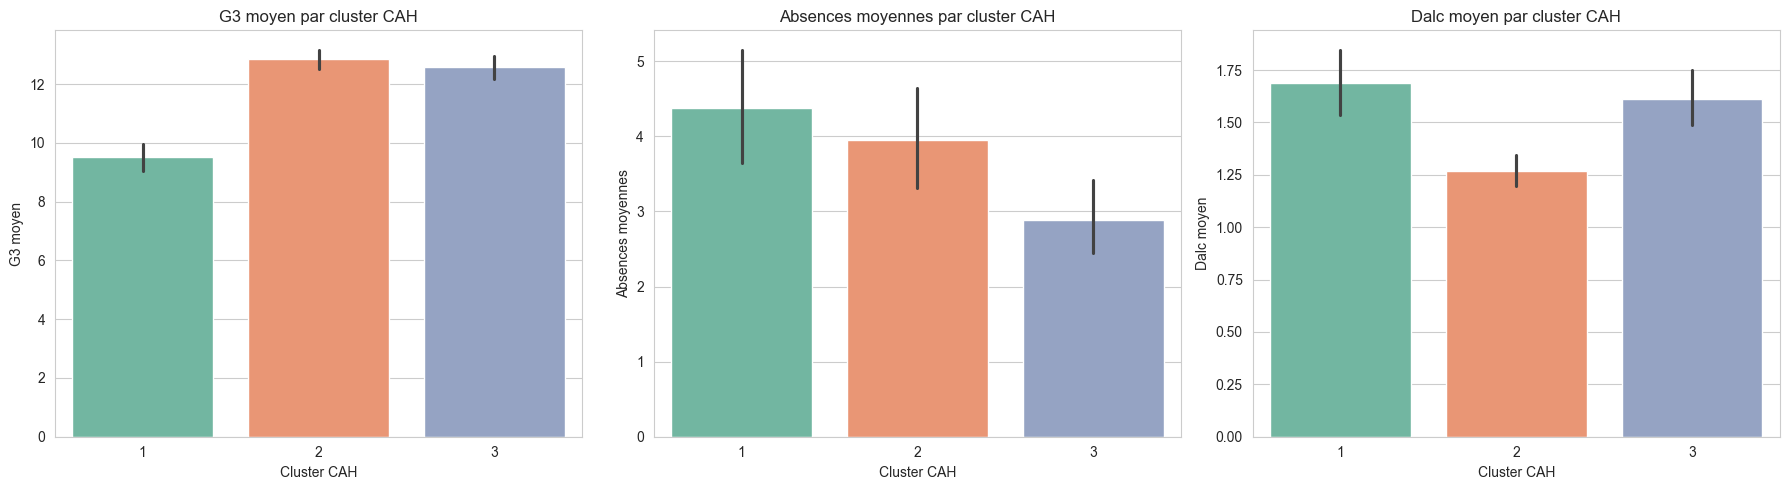


Comparaison CAH vs KMeans par note moyenne de G3 :
CAH_cluster             1          2          3
KMeans_cluster                                 
0               12.208333  13.303665  12.862069
1                8.838462   9.718750   8.767442
2               12.000000  13.421053  13.488372


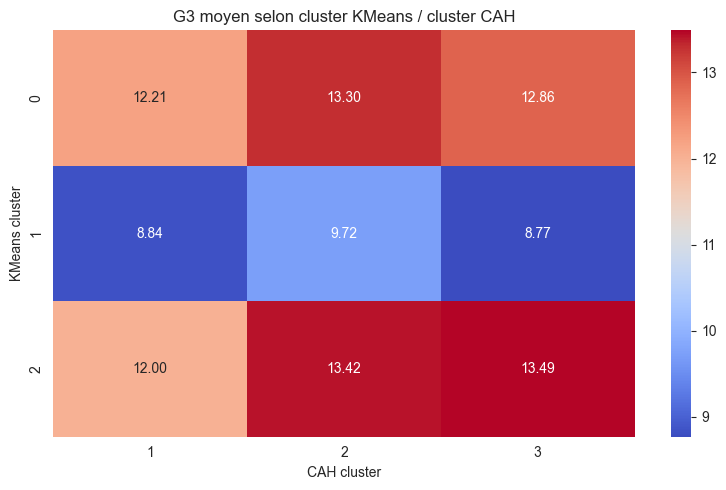

In [42]:
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import silhouette_score, adjusted_rand_score

for name, result in pca_results.items():
    print("\n" + "=" * 60)
    print(f"ANALYSE CAH POST-KMEANS - {name}")
    print("=" * 60)

    Z = linkage(result["X_scaled"], method="ward")
    cah_clusters = fcluster(Z, 3, criterion="maxclust")
    kmeans_clusters = kmeans_results[name]

    print("\nComparaison KMeans vs CAH (effectifs):")
    print(pd.crosstab(kmeans_clusters, cah_clusters, rownames=["KMeans"], colnames=["CAH"]))

    ari = adjusted_rand_score(kmeans_clusters, cah_clusters)
    sil = silhouette_score(result["X_scaled"], cah_clusters)
    print(f"\nAdjusted Rand Index (KMeans vs CAH) : {ari:.3f}")
    print(f"Silhouette score CAH : {sil:.3f}")

    df = df_mat.copy() if name == "Math" else df_por.copy()
    df["CAH_cluster"] = cah_clusters
    df["KMeans_cluster"] = kmeans_clusters

    counts = df["CAH_cluster"].value_counts().sort_index()
    print("\nTaille des clusters CAH :")
    print(counts)

    summary = df.groupby("CAH_cluster").agg(
        G3_mean=("G3", "mean"),
        absences_mean=("absences", "mean"),
        Dalc_mean=("Dalc", "mean"),
        Walc_mean=("Walc", "mean"),
        Medu_mean=("Medu", "mean"),
        Fedu_mean=("Fedu", "mean")
    ).round(2)

    print("\nProfil des clusters CAH (moyennes) :")
    print(summary)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(x="CAH_cluster", y="G3", data=df, estimator="mean", ax=axes[0], palette="Set2")
    sns.barplot(x="CAH_cluster", y="absences", data=df, estimator="mean", ax=axes[1], palette="Set2")
    sns.barplot(x="CAH_cluster", y="Dalc", data=df, estimator="mean", ax=axes[2], palette="Set2")

    axes[0].set_title("G3 moyen par cluster CAH")
    axes[0].set_xlabel("Cluster CAH")
    axes[0].set_ylabel("G3 moyen")

    axes[1].set_title("Absences moyennes par cluster CAH")
    axes[1].set_xlabel("Cluster CAH")
    axes[1].set_ylabel("Absences moyennes")

    axes[2].set_title("Dalc moyen par cluster CAH")
    axes[2].set_xlabel("Cluster CAH")
    axes[2].set_ylabel("Dalc moyen")

    plt.tight_layout()
    plt.show()

    print("\nComparaison CAH vs KMeans par note moyenne de G3 :")
    g3_cmp = df.groupby(["KMeans_cluster", "CAH_cluster"])["G3"].mean().unstack()
    print(g3_cmp)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(g3_cmp, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
    ax.set_title("G3 moyen selon cluster KMeans / cluster CAH")
    ax.set_xlabel("CAH cluster")
    ax.set_ylabel("KMeans cluster")
    plt.tight_layout()
    plt.show()

## CAH approfondie : profil des clusters

Cette section examine les clusters CAH seuls, avec leur taille, les moyennes des variables cl�s, et la comparaison des structures CAH vs KMeans.


CAH PROFIL - Math

Comparaison KMeans vs CAH (effectifs):
CAH       1    2   3
KMeans              
0       119   50   4
1        15   39  18
2        24  100  26

Adjusted Rand Index (KMeans vs CAH) : 0.179
Silhouette score CAH : 0.043

Taille des clusters CAH :
CAH_cluster
1    158
2    189
3     48
Name: count, dtype: int64

Profil d�taill� CAH :
             G3_mean  absences_mean  Dalc_mean  Walc_mean  Medu_mean  \
CAH_cluster                                                            
1              12.17           6.00       1.51       2.30       3.39   
2               9.52           4.98       1.41       2.22       2.34   
3               8.15           7.60       1.67       2.52       2.23   

             Fedu_mean  goout_mean  studytime_mean  
CAH_cluster                                         
1                 3.15        3.03            2.07  
2                 2.13        3.12            2.06  
3                 1.98        3.33            1.81  


C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\3091175129.py:49: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


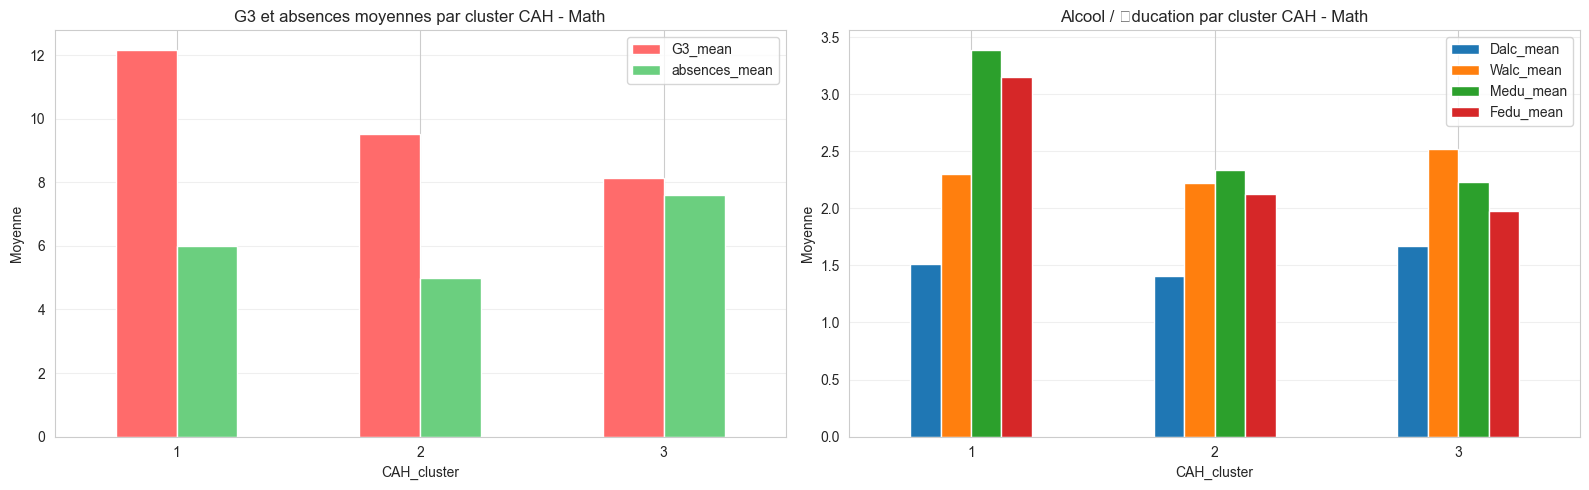


R�partition du sexe et des m�tiers par cluster CAH :

--- sex ---
sex             F     M
CAH_cluster            
1            0.50  0.50
2            0.57  0.43
3            0.46  0.54

--- Mjob ---
Mjob         at_home  health  other  services  teacher
CAH_cluster                                           
1               0.06    0.18   0.13      0.30     0.33
2               0.20    0.02   0.54      0.22     0.02
3               0.23    0.04   0.40      0.29     0.04

--- Fjob ---
Fjob         at_home  health  other  services  teacher
CAH_cluster                                           
1               0.04    0.11   0.28      0.38     0.18
2               0.05    0.00   0.76      0.19     0.00
3               0.06    0.02   0.58      0.33     0.00

--- famsup ---
famsup         no   yes
CAH_cluster            
1            0.30  0.70
2            0.44  0.56
3            0.46  0.54



CAH PROFIL - Portuguese

Comparaison KMeans vs CAH (effectifs):
CAH       1    2    3
KMeans    

C:\Users\HKHD\AppData\Local\Temp\ipykernel_13536\3091175129.py:49: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


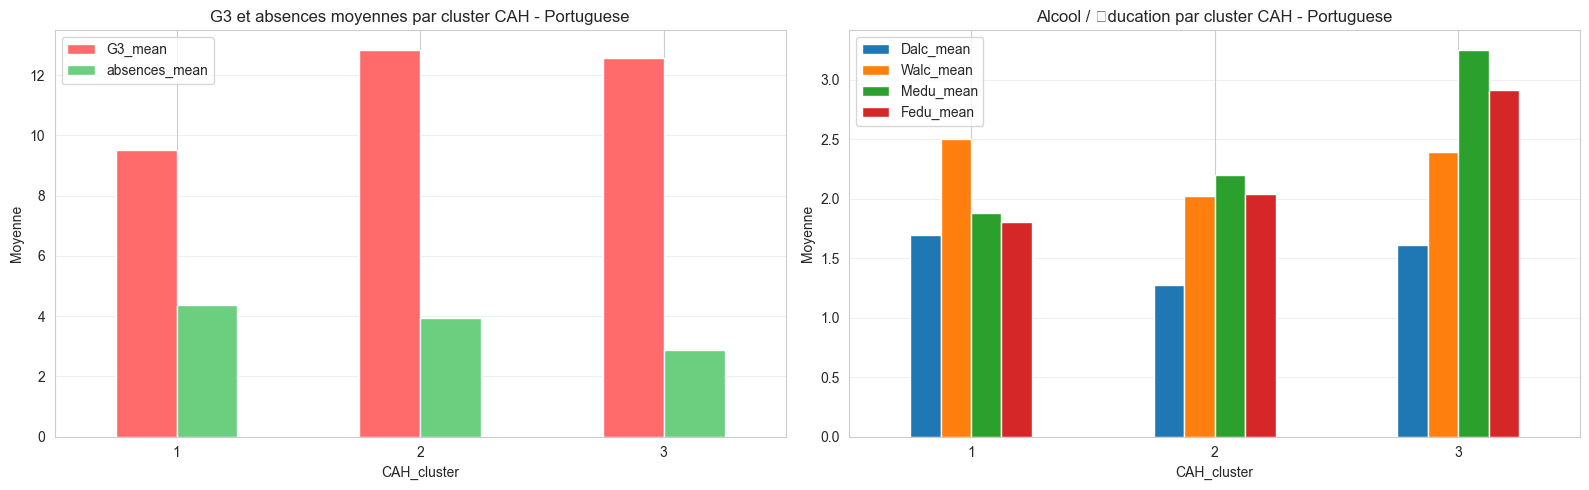


R�partition du sexe et des m�tiers par cluster CAH :

--- sex ---
sex             F     M
CAH_cluster            
1            0.55  0.45
2            0.71  0.29
3            0.49  0.51

--- Mjob ---
Mjob         at_home  health  other  services  teacher
CAH_cluster                                           
1               0.36     0.0   0.48      0.14     0.02
2               0.23     0.0   0.62      0.14     0.01
3               0.09     0.2   0.12      0.32     0.27

--- Fjob ---
Fjob         at_home  health  other  services  teacher
CAH_cluster                                           
1               0.11    0.00   0.61      0.27     0.01
2               0.07    0.00   0.77      0.16     0.00
3               0.03    0.09   0.33      0.40     0.14

--- famsup ---
famsup         no   yes
CAH_cluster            
1            0.44  0.56
2            0.45  0.55
3            0.29  0.71




In [43]:
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import silhouette_score, adjusted_rand_score

for name, result in pca_results.items():
    print("\n" + "=" * 60)
    print(f"CAH PROFIL - {name}")
    print("=" * 60)
    Z = linkage(result["X_scaled"], method="ward")
    cah_clusters = fcluster(Z, 3, criterion="maxclust")
    kmeans_clusters = kmeans_results[name]

    print("\nComparaison KMeans vs CAH (effectifs):")
    print(pd.crosstab(kmeans_clusters, cah_clusters, rownames=["KMeans"], colnames=["CAH"]))

    ari = adjusted_rand_score(kmeans_clusters, cah_clusters)
    sil = silhouette_score(result["X_scaled"], cah_clusters)
    print(f"\nAdjusted Rand Index (KMeans vs CAH) : {ari:.3f}")
    print(f"Silhouette score CAH : {sil:.3f}")

    df = df_mat.copy() if name == "Math" else df_por.copy()
    df["CAH_cluster"] = cah_clusters
    df["KMeans_cluster"] = kmeans_clusters

    print("\nTaille des clusters CAH :")
    print(df["CAH_cluster"].value_counts().sort_index())

    cah_summary = df.groupby("CAH_cluster").agg(
        G3_mean=("G3", "mean"),
        absences_mean=("absences", "mean"),
        Dalc_mean=("Dalc", "mean"),
        Walc_mean=("Walc", "mean"),
        Medu_mean=("Medu", "mean"),
        Fedu_mean=("Fedu", "mean"),
        goout_mean=("goout", "mean"),
        studytime_mean=("studytime", "mean")
    ).round(2)
    print("\nProfil d�taill� CAH :")
    print(cah_summary)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cah_summary[["G3_mean", "absences_mean"]].plot(kind="bar", ax=axes[0], rot=0, color=["#ff6b6b", "#6bcf7f"])
    axes[0].set_title(f"G3 et absences moyennes par cluster CAH - {name}")
    axes[0].set_ylabel("Moyenne")
    axes[0].grid(axis="y", alpha=0.3)
    cah_summary[["Dalc_mean", "Walc_mean", "Medu_mean", "Fedu_mean"]].plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title(f"Alcool / �ducation par cluster CAH - {name}")
    axes[1].set_ylabel("Moyenne")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nR�partition du sexe et des m�tiers par cluster CAH :")
    for cat in ["sex", "Mjob", "Fjob", "famsup"]:
        print(f"\n--- {cat} ---")
        print(df.groupby("CAH_cluster")[cat].value_counts(normalize=True).unstack(fill_value=0).round(2))
    print("\n")